## Imports, paths and raw vals

In [1]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.width", None)        # + better readability
import seaborn as sns
import re
from thefuzz import fuzz
from prepare_data import *
import json
from sklearn.metrics import accuracy_score

In [2]:
raw_path = API_DATA_DIR / 'raw_responses'
csv_path = API_DATA_DIR / 'responses'

In [3]:
cols_to_keep = [
    'model',
    'batch_index',
    'usage'
]

## Model Comparison

### Load and inspect data

In [4]:
files = sorted(raw_path.glob('20260917-*'))

dfs = []

for f in files:
    df_raw = pd.read_json(f, lines=True)[cols_to_keep]
    dfs.append(df_raw)

raw_df = pd.concat(dfs, ignore_index=True)
# unpack usage column
usage_df = pd.json_normalize(raw_df['usage'])
raw_df = pd.concat([raw_df.drop(columns='usage'), usage_df], axis=1)

raw_df.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost,prompt_tokens_details.cache_creation_tokens
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,0.912198,0.844328,0.06787,1.132198,0.844328,0.06787,0.0,0.0,0,0.22,None,None,None,NaN
1,anthropic/claude-sonnet-5,1,5477,528754,534231,1690,1.342278,None,0,1690,None,None,0,0,0,0,0,None,0,1.112278,1.057508,0.05477,1.342278,1.057508,0.05477,0.0,0.0,0,0.23,None,None,None,NaN
2,anthropic/claude-sonnet-5,2,9156,689256,698412,5519,1.710072,None,0,5519,None,None,0,0,0,0,0,None,0,1.470072,1.378512,0.09156,1.710072,1.378512,0.09156,0.0,0.0,0,0.24,None,None,None,NaN
3,anthropic/claude-sonnet-5,3,7346,500708,508054,3612,1.314876,None,0,3612,None,None,0,0,0,0,0,None,0,1.074876,1.001416,0.07346,1.314876,1.001416,0.07346,0.0,0.0,0,0.24,None,None,None,NaN
4,anthropic/claude-sonnet-5,4,9081,711779,720860,4953,1.804368,None,0,4953,None,None,0,0,0,0,0,None,0,1.514368,1.423558,0.09081,1.804368,1.423558,0.09081,0.0,0.0,0,0.29,None,None,None,NaN


In [5]:
sonnet_cache = pd.read_json(raw_path / '20260919-124908-claude-sonnet-5.jsonl', lines=True)[cols_to_keep]
sonnet_usage_df = pd.json_normalize(sonnet_cache['usage'])
sonnet_cache = pd.concat([sonnet_cache.drop(columns='usage'), sonnet_usage_df], axis=1)

sonnet_cache['model'] = sonnet_cache['model'].replace({ 'anthropic/claude-sonnet-5': 'anthropic/claude-sonnet-5-cached' }) # keep cached as own entry
raw_df = pd.concat([sonnet_cache, raw_df], axis=0)
raw_df

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens,prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5-cached,0,3629,450116,453745,372,0.696806,None,0,372,None,None,0,0,156617,291227,0,None,0,156617.0,152494.0,4123.0,0.496806,0.460516,0.036290,0.696806,0.004544,0.036290,0.058245,0.397727,0,0.20,None,None,None
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,0.912198,0.844328,0.067870,1.132198,0.844328,0.067870,0.000000,0.000000,0,0.22,None,None,None
1,anthropic/claude-sonnet-5,1,5477,528754,534231,1690,1.342278,None,0,1690,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,1.112278,1.057508,0.054770,1.342278,1.057508,0.054770,0.000000,0.000000,0,0.23,None,None,None
2,anthropic/claude-sonnet-5,2,9156,689256,698412,5519,1.710072,None,0,5519,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,1.470072,1.378512,0.091560,1.710072,1.378512,0.091560,0.000000,0.000000,0,0.24,None,None,None
3,anthropic/claude-sonnet-5,3,7346,500708,508054,3612,1.314876,None,0,3612,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,1.074876,1.001416,0.073460,1.314876,1.001416,0.073460,0.000000,0.000000,0,0.24,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,openai/gpt-5.6-terra,17,6185,107006,113191,4944,0.389510,None,0,4944,None,None,0,0,1369,5226,0,None,0,1369.0,NaN,NaN,0.279510,0.205290,0.074220,0.389510,0.200822,0.074220,0.001045,0.003422,0,0.11,None,None,None
84,openai/gpt-5.6-terra,18,4740,116565,121305,3512,0.431313,None,0,3512,None,None,0,0,1420,5226,0,None,0,1420.0,NaN,NaN,0.281313,0.224433,0.056880,0.431313,0.219838,0.056880,0.001045,0.003550,0,0.15,None,None,None
85,openai/gpt-5.6-terra,19,4705,87105,91810,3611,0.331970,None,0,3611,None,None,0,0,1414,5226,0,None,0,1414.0,NaN,NaN,0.221970,0.165510,0.056460,0.331970,0.160930,0.056460,0.001045,0.003535,0,0.11,None,None,None
86,openai/gpt-5.6-terra,20,4744,75949,80693,3591,0.280122,None,0,3591,None,None,0,0,1405,5226,0,None,0,1405.0,NaN,NaN,0.200122,0.143194,0.056928,0.280122,0.138636,0.056928,0.001045,0.003512,0,0.08,None,None,None


### Sonnet Cached vs. Non Cached

In [6]:
sonnet_non_cached = pd.read_json(raw_path / '20260917-claude-sonnet-5.jsonl', lines=True)
sonnet_non_cached = sonnet_non_cached[sonnet_non_cached.batch_index == 0]
sonnet_non_cached = sonnet_non_cached[cols_to_keep]
usage_df = pd.json_normalize(sonnet_non_cached['usage'])
sonnet_non_cached = pd.concat([sonnet_non_cached.drop(columns='usage'), usage_df], axis=1)
sonnet_non_cached.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,0.912198,0.844328,0.06787,1.132198,0.844328,0.06787,0,0,0,0.22,None,None,None


In [7]:
sonnet_cache = pd.read_json(raw_path / '20260919-124908-claude-sonnet-5.jsonl', lines=True)[cols_to_keep]
usage_df = pd.json_normalize(sonnet_cache['usage'])
sonnet_cache = pd.concat([sonnet_cache.drop(columns='usage'), usage_df], axis=1)
sonnet_cache

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens,prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5,0,3629,450116,453745,372,0.696806,None,0,372,None,None,0,0,156617,291227,0,None,0,156617,152494,4123,0.496806,0.460516,0.03629,0.696806,0.004544,0.03629,0.058245,0.397727,0,0.2,None,None,None


In [8]:
df = pd.concat([sonnet_non_cached, sonnet_cache], keys=['non_cached', 'cached'], axis=0).droplevel(1)
df.dropna(axis='columns', how='all')

overall_cols = [
    'total_tokens', 
    'cost', #'cost_details.total_cost',     # these two are the same - use only one
    'cost_details.upstream_inference_cost',
    'prompt_tokens_details.cache_creation_tokens',
]

mapper1 = {
    'cost_details.upstream_inference_cost':'upstream_inference_cost',
    'prompt_tokens_details.cache_creation_tokens':'cache_creation_tokens',
}

detail_cols = [
    'completion_tokens',
    'prompt_tokens',
    'reasoning_tokens', # 'completions_tokens_details.reasoning_tokens', # these two are same - use only one 
    'prompt_tokens_details.cache_write_tokens',
    'prompt_tokens_details.cached_tokens',
    'cost_details.upstream_inference_prompt_cost',
    'cost_details.upstream_inference_completions_cost',
    'cost_details.input_cost',
    'cost_details.output_cost',
    'cost_details.cached_input_cost',
    'cost_details.cache_write_input_cost',
    'cost_details.web_search_cost',
    'prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens',
    'prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens'
]

mapper2 = {
    'prompt_tokens_details.cache_write_tokens':'cache_write_tokens',
    'prompt_tokens_details.cached_tokens':'cached_tokens',
    'cost_details.upstream_inference_prompt_cost':'upstream_inference_prompt_cost',
    'cost_details.upstream_inference_completions_cost':'upstream_inference_completions_cost',
    'cost_details.input_cost':'input_cost',
    'cost_details.output_cost':'output_cost',
    'cost_details.cached_input_cost':'cached_input_cost',
    'cost_details.cache_write_input_cost':'cache_write_input_cost',
    'cost_details.web_search_cost':'web_search_cost',
    'prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens':'ephemeral_5m_input_tokens',
    'prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens':'ephemeral_1h_input_tokens'
}

df_overall = df[overall_cols]
df_detailed = df[detail_cols]

df_overall = df_overall.rename(columns=mapper1)
df_detailed = df_detailed.rename(columns=mapper2)


In [9]:
df_detailed

,completion_tokens,prompt_tokens,reasoning_tokens,cache_write_tokens,cached_tokens,upstream_inference_prompt_cost,upstream_inference_completions_cost,input_cost,output_cost,cached_input_cost,cache_write_input_cost,web_search_cost,ephemeral_5m_input_tokens,ephemeral_1h_input_tokens
non_cached,6787,422164,3342,0,0,0.844328,0.06787,0.844328,0.06787,0.000000,0.000000,0.22,NaN,NaN
cached,3629,450116,372,156617,291227,0.460516,0.03629,0.004544,0.03629,0.058245,0.397727,0.20,152494.0,4123.0


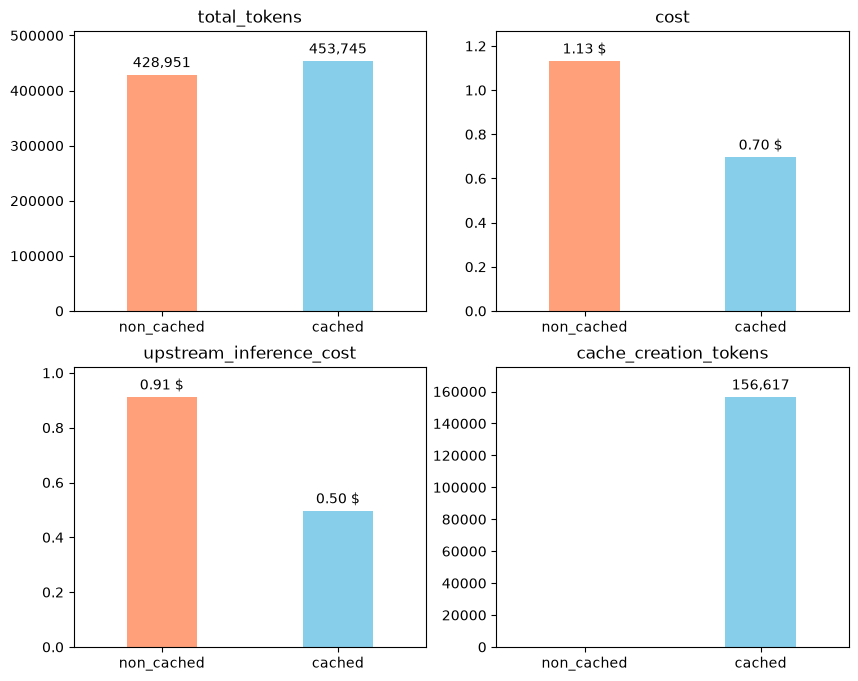

In [10]:
row_colors = {"non_cached": "lightsalmon", "cached": "skyblue"}

x = np.arange(len(df_overall.index))
labels = df_overall.index.astype(str)
colors = [row_colors[i] for i in df_overall.index]

def fmt(col, v):
    if pd.isna(v):
        return ""
    if "cost" in col.lower():
        return f"{v:,.2f} $"
    return f"{v:,.0f}"

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, df_overall.columns):
    bars = ax.bar(x, df_overall[col], width=0.4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(col)
    ax.margins(y=0.12)
    ax.bar_label(bars, labels=[fmt(col, v) for v in df_overall[col]], padding=3)

handles = [mpatches.Patch(color=c, label=l) for l, c in row_colors.items()]
plt.show()


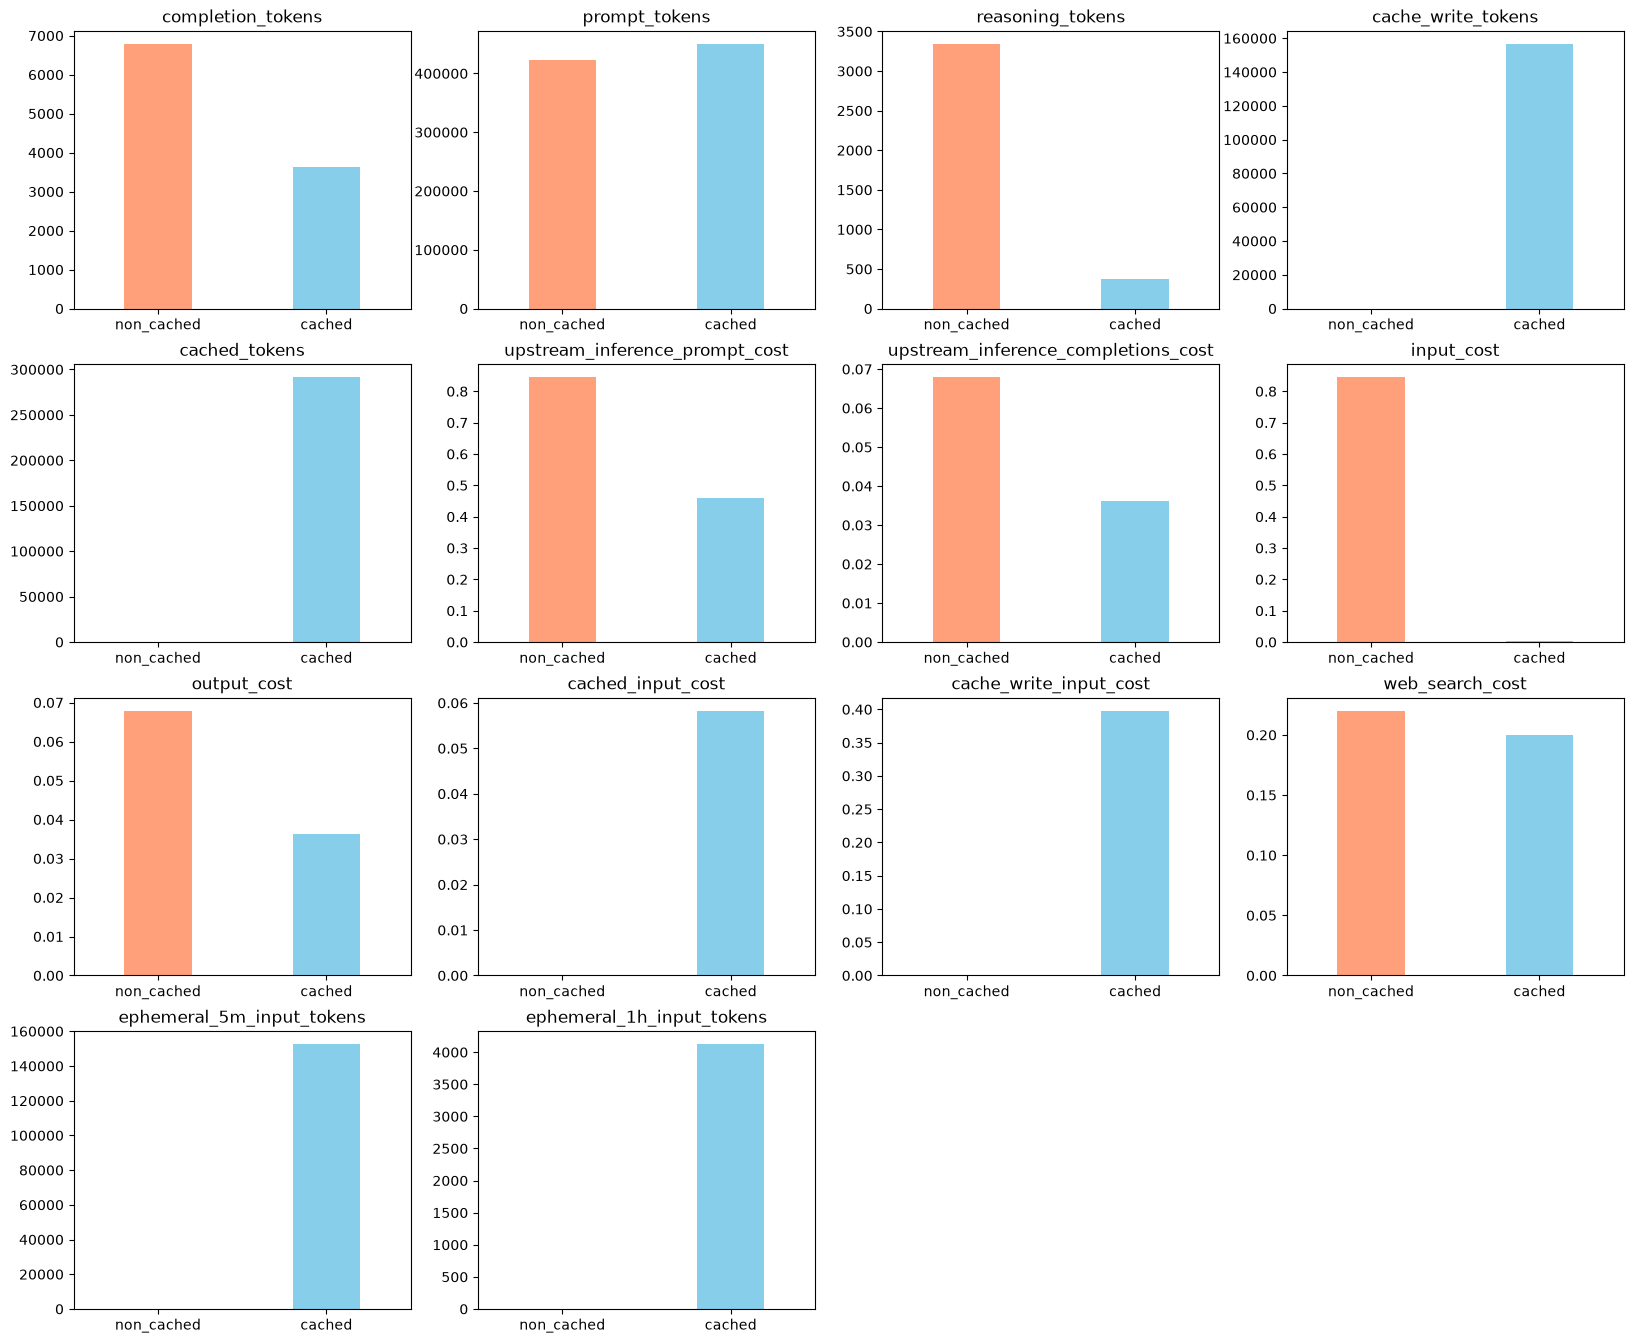

In [11]:
num_cols = df_detailed.columns
n = len(num_cols)
nrows = -(-n // 4)

x = np.arange(len(df_detailed.index))
labels = df_detailed.index.astype(str)
colors = [row_colors[i] for i in df_detailed.index]

fig, axes = plt.subplots(nrows, 4, figsize=(20, 4 * nrows + 0.6))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.bar(x, df_detailed[col], width=0.4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis("off")

handles = [mpatches.Patch(color=c, label=l) for l, c in row_colors.items()]
plt.show()


In [12]:
cols_to_keep = [
    'model', 'batch_index', 'answer'
]

files = sorted(csv_path.glob('20260917-*'))

dfs = []
for f in files:
    df = pd.read_csv(f, usecols=cols_to_keep)
    df['answer'] = df['answer'].apply(json.loads)
    df_answer = pd.json_normalize(df['answer'])
    df = df.drop(columns=['answer']).join(df_answer)
    df['model'] = df['model'].str.split('/').str[1]
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()

,model,batch_index,id,name,hasFoundMenu,menuLink,format,source
0,claude-sonnet-5,0,ChIJAV1_vX1SUkYRifHQGs0-33o,Pizze Di Napo Hellerup,True,https://pizzedinapohellerup.dk/,HTML,OFFICIAL_WEBSITE
1,claude-sonnet-5,0,ChIJ7RIaXXpQUkYRxGD3xBRRltk,McDonald's,True,https://www.mcdonalds.com/dk/da-dk/vores-menu....,HTML,OFFICIAL_WEBSITE
2,claude-sonnet-5,0,ChIJq6p-9w9TUkYRGJ7PByHSDYY,Byens Pizza,True,http://byens-pizza.dk/?page_id=2065,HTML,OFFICIAL_WEBSITE
3,claude-sonnet-5,0,ChIJz3lHpeRSUkYRRNH0_-MSMhU,Restaurant Taormina v/Mukuntharaj Karunaratnam,True,https://taormina.dk/menu/,HTML,OFFICIAL_WEBSITE
4,claude-sonnet-5,0,ChIJBVGBtQFTUkYR7R1FSqjW1kg,Barnetsfest,False,,,


### Model Agreement on menuLinks after cleaning URLs

- Ignoring prefix such as `http`, `https://`, `www.` etc.
- Suffix `/`

In [13]:
url_prefix_pattern = re.compile(r'^(?:https?://)?(?:www\.)?', re.IGNORECASE)

df['normalized_urls'] = df['menuLink'].str.replace(url_prefix_pattern, '', regex=True)
df['normalized_urls'] = df['normalized_urls'].str.rstrip('/')
df_menulinks = df.pivot_table(index='id', columns='model', values='normalized_urls', aggfunc='first')
df_menulinks.head()

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,restaurantalf.dk,restaurantalf.dk,restaurantalf.dk,restaurantalf.dk
ChIJ-QrW55VTUkYRiO5rYIpA5PE,durumbar-frb.dk,durumbar78.dk,durumbar2000.dk,ubereats.com/dk-en/store/durum-bar-2000/KBI4og...
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,royalbagel.dk/royal-bagel-valby-langgade/takeaway,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,ubereats.com/dk-en/store/royal-bagel-valby/sjJ...
ChIJ-YewRThSUkYRU-ZX1KiCAr0,nordvestpizzaria.dk,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,eatonline.dk/restaurant/172/nord-vest-pizza-gr...
ChIJ-ao52_ZNUkYRU11OTne3ec8,joejuice.com,joejuice.com/menu,joejuice.com/?market=dk,ubereats.com/dk-en/store/joe-%26-the-juice-gen...


In [14]:
gpt_menulinks = df_menulinks[['gpt-5.6-luna', 'gpt-5.6-terra']]
accscore = accuracy_score(gpt_menulinks['gpt-5.6-luna'], gpt_menulinks['gpt-5.6-terra'])
print(f"Accuracy score between the two GPT models, when matching on a 'normalized' url: {round(accscore * 100, 2)}%")

Accuracy score between the two GPT models, when matching on a 'normalized' url: 55.58%


### Using Fuzzing to determine the ratio

##### GPT Only

In [15]:
gpt_fuzz = gpt_menulinks.copy()
gpt_fuzz['fuzz_ratio'] = [
    float(fuzz.ratio(luna, terra))
    for luna, terra in zip(gpt_fuzz['gpt-5.6-luna'], gpt_fuzz['gpt-5.6-terra'])
]
gpt_fuzz = gpt_fuzz.rename_axis('restaurant_id').reset_index()
gpt_fuzz.sort_values(by=['fuzz_ratio'], inplace=True)
gpt_fuzz.head()

model,restaurant_id,gpt-5.6-luna,gpt-5.6-terra,fuzz_ratio
141,ChIJK6ULsApTUkYRf5h0Q2IlXIs,ubereats.com/dk-en/store/flos-pizza/k6TaKUdzWA...,,0.0
401,ChIJuVCd7FVTUkYRid7lp9YUd0g,,baglokalet.dk/restaurant,0.0
357,ChIJmcsRfn5SUkYRmvHf77tmn7g,,menu02.restaurantguru.com/m7/menu-Cannillo-5mh...,0.0
77,ChIJB0yyYxxTUkYRKjbWYP1K57M,,wolt.com/da/dnk/copenhagen/restaurant/it-s-sma...,0.0
75,ChIJAzGKQYpTUkYRLkFWaLyI6Ds,juliliving.dk/siljangade,,0.0


##### All Models (NOT SURE ABOUT THIS)

In [16]:
def safe_ratio(u1, u2):
    if pd.isna(u1) or pd.isna(u2) or u1 == '' or u2 == '':
        return np.nan
    return fuzz.ratio(u1, u2)

model_url_agreement = {}

for model_1 in df_menulinks.columns:
    scores = df_menulinks[[model_1]].rename(columns={model_1: 'url'})
    
    for model_2 in df_menulinks.columns:
        if model_2 == model_1:
            continue
        scores[model_2] = [safe_ratio(u1, u2) for u1, u2 in zip(df_menulinks[model_1], df_menulinks[model_2])]
    model_url_agreement[model_1] = scores

model_url_agreement['gpt-5.6-luna'].head(10)

model,url,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,restaurantalf.dk,100.0,100.0,100.0
ChIJ-QrW55VTUkYRiO5rYIpA5PE,durumbar2000.dk,73.0,79.0,31.0
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,44.0,100.0,53.0
ChIJ-YewRThSUkYRU-ZX1KiCAr0,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,45.0,100.0,100.0
ChIJ-ao52_ZNUkYRU11OTne3ec8,joejuice.com/?market=dk,69.0,75.0,24.0
ChIJ-dcIKQ9TUkYRCnX2QWVgSG4,froekensandwich.dk,88.0,85.0,100.0
ChIJ-dqxj6xTUkYR6bN0GtI7dCs,durumsymfoni.dk,28.0,36.0,100.0
ChIJ-fk2NRBTUkYRyhj40xrfESA,earlybird.dk/restaurant/a-terre,47.0,30.0,40.0
ChIJ-xIoQDlTUkYRQYAPd7S0xRA,,NaN,NaN,NaN


In [19]:
df_r = pd.read_json(RAW_DATA_DIR / 'copenhagen-bounds-full-raw.json')
df_p = pd.read_json(RAW_DATA_DIR / 'copenhagen-10pct-sample-input-2026-09-17.json')
join = pd.merge(df_r, df_p, on='id')
join.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 69 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name_x                        439 non-null    str    
 1   id                            439 non-null    str    
 2   types                         439 non-null    object 
 3   nationalPhoneNumber           376 non-null    str    
 4   internationalPhoneNumber      376 non-null    str    
 5   formattedAddress_x            439 non-null    str    
 6   addressComponents             439 non-null    object 
 7   plusCode                      438 non-null    object 
 8   location                      439 non-null    object 
 9   viewport                      439 non-null    object 
 10  rating                        410 non-null    float64
 11  googleMapsUri                 439 non-null    str    
 12  websiteUri_x                  354 non-null    str    
 13  regularOpeningHo

In [20]:
join.businessStatus.value_counts()

businessStatus
OPERATIONAL           414
CLOSED_TEMPORARILY     25
Name: count, dtype: int64

In [21]:
df = pd.read_json(RAW_DATA_DIR / 'copenhagen-bounds-full-raw.json')
df = df[df["businessStatus"] == "OPERATIONAL"]
df.info()

<class 'pandas.DataFrame'>
Index: 4200 entries, 0 to 4391
Data columns (total 66 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          4200 non-null   str    
 1   id                            4200 non-null   str    
 2   types                         4200 non-null   object 
 3   nationalPhoneNumber           3613 non-null   str    
 4   internationalPhoneNumber      3613 non-null   str    
 5   formattedAddress              4200 non-null   str    
 6   addressComponents             4200 non-null   object 
 7   plusCode                      4189 non-null   object 
 8   location                      4200 non-null   object 
 9   viewport                      4200 non-null   object 
 10  rating                        3863 non-null   float64
 11  googleMapsUri                 4200 non-null   str    
 12  websiteUri                    3463 non-null   str    
 13  regularOpeningHours

In [22]:
join.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 69 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name_x                        439 non-null    str    
 1   id                            439 non-null    str    
 2   types                         439 non-null    object 
 3   nationalPhoneNumber           376 non-null    str    
 4   internationalPhoneNumber      376 non-null    str    
 5   formattedAddress_x            439 non-null    str    
 6   addressComponents             439 non-null    object 
 7   plusCode                      438 non-null    object 
 8   location                      439 non-null    object 
 9   viewport                      439 non-null    object 
 10  rating                        410 non-null    float64
 11  googleMapsUri                 439 non-null    str    
 12  websiteUri_x                  354 non-null    str    
 13  regularOpeningHo

In [23]:
# remove out of order restaurants
join = join[join["businessStatus"] == "OPERATIONAL"]

join.info()

<class 'pandas.DataFrame'>
Index: 414 entries, 0 to 438
Data columns (total 69 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name_x                        414 non-null    str    
 1   id                            414 non-null    str    
 2   types                         414 non-null    object 
 3   nationalPhoneNumber           358 non-null    str    
 4   internationalPhoneNumber      358 non-null    str    
 5   formattedAddress_x            414 non-null    str    
 6   addressComponents             414 non-null    object 
 7   plusCode                      413 non-null    object 
 8   location                      414 non-null    object 
 9   viewport                      414 non-null    object 
 10  rating                        386 non-null    float64
 11  googleMapsUri                 414 non-null    str    
 12  websiteUri_x                  337 non-null    str    
 13  regularOpeningHours  

In [24]:
# possible "proper" restaurant types that aren't named restaurant or *_restaurant
other_types_to_keep = ["bagel_shop", "bistro", "diner", "pizza_delivery"]
# not considered "proper" restaurant
discard_restaurants = ["shawarma_restaurant", "hot_dog_restaurant"]

is_restaurant = join["primaryType"].str.fullmatch(r"(.+_)?restaurant", na=False) | join["primaryType"].isin(other_types_to_keep)
join = join[is_restaurant & ~join["primaryType"].isin(discard_restaurants)]
join.info()

<class 'pandas.DataFrame'>
Index: 304 entries, 0 to 436
Data columns (total 69 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name_x                        304 non-null    str    
 1   id                            304 non-null    str    
 2   types                         304 non-null    object 
 3   nationalPhoneNumber           265 non-null    str    
 4   internationalPhoneNumber      265 non-null    str    
 5   formattedAddress_x            304 non-null    str    
 6   addressComponents             304 non-null    object 
 7   plusCode                      303 non-null    object 
 8   location                      304 non-null    object 
 9   viewport                      304 non-null    object 
 10  rating                        281 non-null    float64
 11  googleMapsUri                 304 non-null    str    
 12  websiteUri_x                  247 non-null    str    
 13  regularOpeningHours  